<h1>Mindestanforderungen 4</h1>

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from currency_converter import CurrencyConverter
c = CurrencyConverter()
from datetime import date

In [25]:
df = pd.read_csv("stack-overflow-developer-survey-2025/survey_results_public_without_SO.csv")

df.head()

,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [ ]:
# Alter in numerischen Wert umwandeln

age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}

df['AgeNum'] = df['Age'].map(age_map)

#print (df['AgeNum'].describe())


#df[df['AgeNum'] == 70]
# Alle Ü65 rausschmeißen
df = df[df['AgeNum'] <= 65]


Erstellen Sie mindestens 2 neue Features

In [29]:
# Mit Currency Converter Jahresgehalt in USD umwandeln

# Currency Spalte alles nach den ersten 3 Buchstaben abschneiden
df['Currency'] = df['Currency'].str[:3]

# Spalte CompTotal in USD umwandeln und in Spalte convertedCompTotal speichern

def convert_to_usd(currency, comp):
    if currency not in c.currencies:
        return np.nan
    if currency == "RUB":
        converted = c.convert(comp, currency, 'USD', date=date(2022, 3, 1))
    elif currency == "HRK":
        converted = c.convert(comp, currency, 'USD', date=date(2022, 12, 30))
    else:
        converted = c.convert(comp, currency, 'USD', date=date(2025, 10, 6))
    return converted

df['ConvertedCompTotal'] = df.apply(lambda row: convert_to_usd(row['Currency'], row['CompTotal']), axis=1)

df['ConvertedCompTotal'].describe()


df['ConvertedCompTotal'].quantile(0.95)

#df['ConvertedCompTotal']



np.float64(236000.0)

In [22]:
q95 = (df[df['ConvertedCompTotal'] <= df['ConvertedCompTotal'].quantile(0.95)])

In [23]:
q95['ConvertedCompTotal'].describe()

count     21120.000000
mean      80902.253104
std       55463.504486
min           0.000000
25%       40000.000000
50%       74713.827082
75%      115140.000000
max      235282.856528
Name: ConvertedCompTotal, dtype: float64

Untersuchen Sie die Korrelationen gesamthaft und graphisch für mindestens 2 Feature-Kombinationen

In [ ]:
# Bei Moritz zu finden

Erstellen / Konvertieren Sie eine Time Series

In [ ]:
# Wechselkurse analysieren
# Line Chart USD von jedem Tag

start = "2025-06-30"
end = "2025-11-03"

dates = pd.bdate_range(start, end)
print (dates)

def get_rates(date, curr):
    cc = c.convert(1, curr, 'USD', date=date)
    return cc

rates = []

for d in dates:
    rate = get_rates(d, 'EUR')
    rates.append(rate)

frame = pd.DataFrame({'date': dates})
frame.set_index('date', inplace=True)

frame['EUR'] = rates

rates = []

for d in dates:
    rate = get_rates(d, 'GBP')
    rates.append(rate)

frame['GBP'] = rates

rates = []

for d in dates:
    rate = get_rates(d, 'INR')
    rates.append(rate)

frame['INR'] = rates

rates = []

for d in dates:
    rate = get_rates(d, 'CAD')
    rates.append(rate)

frame['CAD'] = rates

frame

    

DatetimeIndex(['2025-06-30', '2025-07-01', '2025-07-02', '2025-07-03',
               '2025-07-04', '2025-07-07', '2025-07-08', '2025-07-09',
               '2025-07-10', '2025-07-11', '2025-07-14', '2025-07-15',
               '2025-07-16', '2025-07-17', '2025-07-18', '2025-07-21',
               '2025-07-22', '2025-07-23', '2025-07-24', '2025-07-25',
               '2025-07-28', '2025-07-29', '2025-07-30', '2025-07-31',
               '2025-08-01', '2025-08-04', '2025-08-05', '2025-08-06',
               '2025-08-07', '2025-08-08', '2025-08-11', '2025-08-12',
               '2025-08-13', '2025-08-14', '2025-08-15', '2025-08-18',
               '2025-08-19', '2025-08-20', '2025-08-21', '2025-08-22',
               '2025-08-25', '2025-08-26', '2025-08-27', '2025-08-28',
               '2025-08-29', '2025-09-01', '2025-09-02', '2025-09-03',
               '2025-09-04', '2025-09-05', '2025-09-08', '2025-09-09',
               '2025-09-10', '2025-09-11', '2025-09-12', '2025-09-15',
      

,EUR,GBP,INR,CAD
date,,,,
2025-06-30,1.1720,1.369959,0.011655,0.731266
2025-07-01,1.1810,1.375175,0.011687,0.734635
2025-07-02,1.1755,1.366066,0.011673,0.732810
2025-07-03,1.1782,1.365396,0.011713,0.735915
2025-07-04,1.1767,1.364290,0.011709,0.735667
...,...,...,...,...
2025-10-28,1.1630,1.327626,0.011323,0.714198
2025-10-29,1.1636,1.321222,0.011334,0.717961
2025-10-30,1.1550,1.312351,0.011272,0.713888


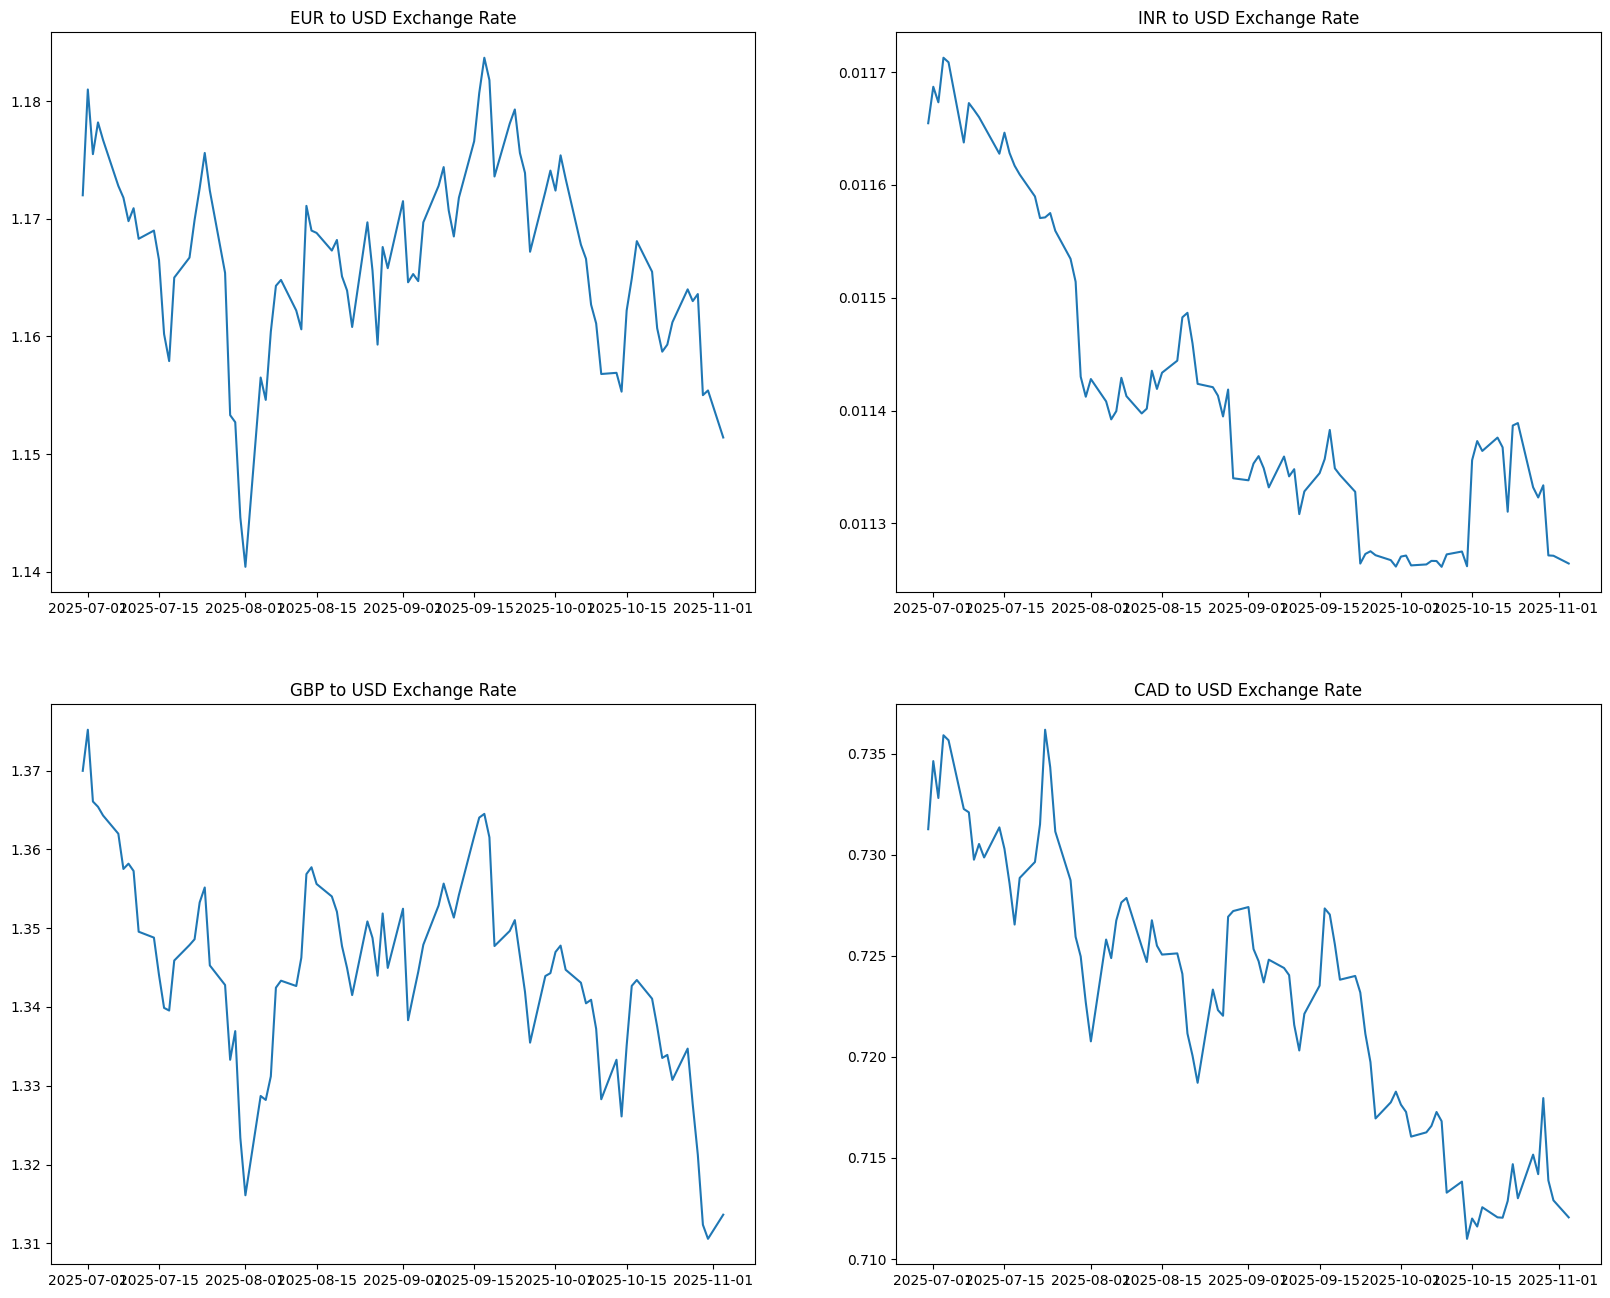

In [72]:
fig, ax = plt.subplots(2,2,figsize=(20, 16))

ax[0,0].set_title('EUR to USD Exchange Rate')
ax[0,0].plot(frame.index, frame['EUR'])

ax[0,1].set_title('INR to USD Exchange Rate')
ax[0,1].plot(frame.index, frame['INR'])

ax[1,0].set_title('GBP to USD Exchange Rate')
ax[1,0].plot(frame.index, frame['GBP'])

ax[1,1].set_title('CAD to USD Exchange Rate')
ax[1,1].plot(frame.index, frame['CAD'])

plt.show()


Erstellen Sie eine Analyse basierend auf den Zeitdaten

In [ ]:


start = "2025-06-30"
end = "2025-11-03"

dates = pd.bdate_range(start, end)

def get_rates(date, curr):
    cc = c.convert(1, curr, 'USD', date=date)
    return cc

frame1 = pd.DataFrame({'date': dates}).set_index('date')

for curr in ['EUR', 'GBP', 'INR', 'CAD']:
    rates = []
    for d in dates:
        rates.append(get_rates(d, curr))
    frame1[curr] = rates

# Tag mit minimaler lokaler Volatilität

# tägliche prozentuale Änderungen (Returns)
returns = frame1[['EUR', 'GBP', 'INR', 'CAD']].pct_change()

# rollierende Standardabweichung über 7 Tage
window = 7  # ca. ±3 Handelstage
rolling_vol = returns.rolling(window=window, center=True).std()

# gemeinsamen Volatilitäts-Score pro Tag bilden
vol_score = rolling_vol.mean(axis=1)

# Tage ohne vollständige Daten entfernen
vol_score = vol_score.dropna()

# Tag mit minimaler Volatilität bestimmen
best_date = vol_score.idxmin()
best_score = vol_score.loc[best_date]

print("Empfohlener Stichtag:", best_date.date())
print("Volatilitäts-Score an diesem Tag:", best_score)


Empfohlener Stichtag: 2025-10-06
Volatilitäts-Score an diesem Tag: 0.0013592461552492626
